# Melakukan install dan import library yang diperlukan

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 6.4 MB/s eta 0:00:00


Langkah awal yang dilakukan adalah melakukan download dan import library yang akan digunakan. Salah satunya ada library sastrawi yang akan digunakan memproses teks Bahasa Indonesia. Library ini penting karena data yang digunakan nanti merupakan data berbahasa Indonesia.

In [3]:
import pandas as pd
pd.options.mode.chained_assignment = None
import numpy as np
seed = 0
np.random.seed(seed)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
import csv
import requests
from io import StringIO

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, precision_score

import datetime as dt
import re
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.util import ngrams

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

from wordcloud import WordCloud

import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

Setelah melakukan download dan import library yang akan digunakan, selanjutnya adalah melakukan load dataset

# Melakukan Load Dataset

Dataset yang digunakan pada proyek ini adalah dataset hasil scrapping ulasan aplikasi tokopedia. Sebelum digunakan, dataset terlebih dulu dicek dan dibersihkan dari data hilang, duplikat, dan yang tidak diperlukan agar hasil yang diperoleh juga akurat.

In [4]:
app_reviews_df = pd.read_csv('/content/drive/MyDrive/Submission Belajar Fundamental Deep Learning/ulasan_tokped.csv')

In [5]:
app_reviews_df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,3050652b-7601-4b69-90ee-5cac72eb83d5,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,saya baru gabung dan pengguna baru di tokopedi...,3,0,3.359.0,2026-04-16 01:01:25,NaN,NaN,3.359.0
1,f6c4d63f-d265-4f34-ad6a-fe2cc8ac19fd,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,koin gopay yg (katanya) bisa mengurangi biaya ...,3,1,3.359.0,2026-04-13 11:54:25,NaN,NaN,3.359.0
2,3ab8e229-7a77-4034-a305-40b34a1d9a38,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Overall bagus-bagus aja. Cuma tolong dikasih j...,5,1,3.358.0,2026-04-14 00:39:23,NaN,NaN,3.358.0
3,32473367-a15a-45e9-afbd-fc5104cae77f,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Tolong Tokopedia perbaiki bug pencarian di wis...,1,1,3.358.0,2026-04-13 23:58:58,NaN,NaN,3.358.0
4,78ac3ecd-c84b-41c0-8f85-32fdbc91e22a,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sepertinya tokopedia harus ganti partner logis...,1,5,3.358.0,2026-04-01 15:41:57,NaN,NaN,3.358.0


In [6]:
app_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 283500 entries, 0 to 283499
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   reviewId              283500 non-null  object
 1   userName              283500 non-null  object
 2   userImage             283500 non-null  object
 3   content               283500 non-null  object
 4   score                 283500 non-null  int64 
 5   thumbsUpCount         283500 non-null  int64 
 6   reviewCreatedVersion  191648 non-null  object
 7   at                    283500 non-null  object
 8   replyContent          118010 non-null  object
 9   repliedAt             118010 non-null  object
 10  appVersion            191648 non-null  object
dtypes: int64(2), object(9)
memory usage: 23.8+ MB


Sebelum dibersihkan dapat dilihat bahwa terdapat 283500 baris data, dengan 11 kolom

In [7]:
clean_df = app_reviews_df.dropna()

In [8]:
clean_df = clean_df.drop_duplicates()
jumlah_ulasan_setelah_hapus_duplikat, Jumlah_kolom_setelah_hapus_duplikat = clean_df.shape

In [9]:
clean_df = clean_df.reset_index(drop=True)

In [10]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86487 entries, 0 to 86486
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              86487 non-null  object
 1   userName              86487 non-null  object
 2   userImage             86487 non-null  object
 3   content               86487 non-null  object
 4   score                 86487 non-null  int64 
 5   thumbsUpCount         86487 non-null  int64 
 6   reviewCreatedVersion  86487 non-null  object
 7   at                    86487 non-null  object
 8   replyContent          86487 non-null  object
 9   repliedAt             86487 non-null  object
 10  appVersion            86487 non-null  object
dtypes: int64(2), object(9)
memory usage: 7.3+ MB


Setelah melakukan pembersihan data, kini tersisa 86487 baris data. Data yang tersisa inilah yang akan digunakan dalam proyek ini

# Preprocessing Text

Pada bagian ini, dilakukan prepocessing teks sebelum masuk kedalam pelabelan. Preprocessing bertujuan untuk menyeragamkan data teks yang akan digunakan pada proyek ini. Terdapat bebera fungsi yang digunakan pada proses preprocessing ini, diantaranya:
1. cleaningText(text): Membersihkan teks dengan menghapus mention, hashtag, RT (retweet), tautan (link), angka, dan tanda baca. Selain itu, karakter newline diganti dengan spasi dan spasi ekstra pada awal dan akhir teks dihapus.
2. casefoldingText(text): Mengonversi semua karakter dalam teks menjadi huruf kecil (lowercase) untuk membuat teks menjadi seragam.
3. tokenizingText(text): Memecah teks menjadi daftar kata atau token. Ini membantu dalam mengurai teks menjadi komponen-komponen dasar untuk analisis lebih lanjut.
4. filteringText(text): Menghapus kata-kata berhenti (stopwords) dalam teks. Daftar kata-kata berhenti telah diperbarui dengan beberapa kata tambahan.
5. stemmingText(text): Menerapkan stemming pada teks, yakni mengurangi kata-kata menjadi bentuk dasarnya. Disini pustaka Sastrawi digunakan untuk melakukan stemming dalam bahasa Indonesia.
6. toSentence(list_words): Menggabungkan daftar kata-kata menjadi sebuah kalimat.


In [11]:
def cleaningText(text):
  text = re.sub(r'@[A-Za-z0-9]+', '', text)
  text = re.sub(r'#[A-Za-z0-9]+', '', text)
  text = re.sub(r'RT[\s]', '', text)
  text = re.sub(r"http\S+", '', text)
  text = re.sub(r'[0-9]+', '', text)
  text = re.sub(r'[^\w\s]', '', text)

  text = text.replace('\n', ' ')
  text = text.translate(str.maketrans('', '', string.punctuation))
  text = text.strip(' ')
  return text

def casefoldingText(text):
  text = text.lower()
  return text

def tokenizingText(text):
  text = word_tokenize(text)
  return text

def filteringText(text):
  listStopwords = set(stopwords.words('indonesian'))
  listStopwords1 = set(stopwords.words('english'))
  listStopwords.update(listStopwords1)
  listStopwords.update(['iya','yaa','gak','nya','na','sih','ku',"di","ga","ya","gaa","loh","kah","woi","woii","woy"])
  filtered = []
  for txt in text:
    if txt not in listStopwords:
      filtered.append(txt)
      text = filtered
    return text

def stemmingText(text):
  factory = StemmerFactory()
  stemmer = factory.create_stemmer()
  words = text.split()
  stemmed_words = [stemmer.stem(word) for word in words]
  stemmed_text = ' '.join(stemmed_words)
  return stemmed_text

def toSentence(list_words):
  sentence = ' '.join(word for word in list_words)
  return sentence

kemudian, penghapus kumpulan slang words atau kata-kata informal yang sering digunakan

In [12]:
slangwords = {"@": "di", "abis": "habis", "wtb": "beli", "masi": "masih", "wts": "jual", "wtt": "tukar", "bgt": "banget", "maks": "maksimal" }
def fix_slangwords(text):
  words = text.split()
  fixed_words = []
  for word in words:
    if word.lower() in slangwords:
      fixed_words.append(slangwords[word.lower()])
    else:
      fixed_words.append(word)

  fixed_text = ' '.join(fixed_words)
  return fixed_text

In [13]:
clean_df['text_clean'] = clean_df['content'].apply(cleaningText)
clean_df['text_casefoldingText'] = clean_df['text_clean'].apply(casefoldingText)
clean_df['text_slangwords'] = clean_df['text_casefoldingText'].apply(fix_slangwords)
clean_df['text_tokenizingText'] = clean_df['text_slangwords'].apply(tokenizingText)
clean_df['text_stopword'] = clean_df['text_tokenizingText'].apply(filteringText)
clean_df['text_akhir'] = clean_df['text_stopword'].apply(toSentence)

Selanjutnya adalah menerapkan hasil preprocessing yang telah dilakukan sebelumnya

In [14]:
clean_df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_akhir
0,f26547f5-b0b7-496d-9831-82da8738bc11,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Achir2 ini, Tokopedia menawarkan barang dengan...",3,60,3.358.0,2026-03-31 22:46:58,"Terima kasih atas rating yang kamu berikan, To...",2023-01-16 14:41:08,3.358.0,Achir ini Tokopedia menawarkan barang dengan h...,achir ini tokopedia menawarkan barang dengan h...,achir ini tokopedia menawarkan barang dengan h...,"[achir, ini, tokopedia, menawarkan, barang, de...",[achir],achir
1,c947e12b-720a-4da9-bec8-bf74e6a1688b,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Tokopedia mulai sewenang², seenaknya merubah j...",1,4,3.358.0,2026-04-12 22:42:26,"Toppers, mohon maaf atas kendala yang kamu ala...",2024-03-16 22:00:01,3.358.0,Tokopedia mulai sewenang² seenaknya merubah ja...,tokopedia mulai sewenang² seenaknya merubah ja...,tokopedia mulai sewenang² seenaknya merubah ja...,"[tokopedia, mulai, sewenang², seenaknya, merub...",[tokopedia],tokopedia
2,f06d107e-0625-4c66-b94b-3ce812383b97,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Hasil pencariannya goblog, tolol!!. Sudah paka...",1,52,3.360.0,2026-04-15 06:59:59,"Toppers, mohon maaf atas kendala yang kamu ala...",2025-02-24 16:20:14,3.360.0,Hasil pencariannya goblog tolol Sudah pakai ka...,hasil pencariannya goblog tolol sudah pakai ka...,hasil pencariannya goblog tolol sudah pakai ka...,"[hasil, pencariannya, goblog, tolol, sudah, pa...",[hasil],hasil
3,23daa6bf-270d-4d15-951f-77b9fa3ab3e3,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,semakin kesini semakin parah aja Tokopedia bel...,1,0,3.359.0,2026-04-15 08:21:55,Maaf ya Kak Wawan atas ketidaknyamanannya. Ter...,2020-10-18 17:37:23,3.359.0,semakin kesini semakin parah aja Tokopedia bel...,semakin kesini semakin parah aja tokopedia bel...,semakin kesini semakin parah aja tokopedia bel...,"[semakin, kesini, semakin, parah, aja, tokoped...","[semakin, kesini, semakin, parah, aja, tokoped...",semakin kesini semakin parah aja tokopedia bel...
4,52ac95af-8a9a-4b75-ac87-68d492f91a13,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"berhati hati lah untuk bertransaksi di sini, b...",1,2,3.358.0,2026-04-03 16:23:45,"Hi Toppers, silakan sampaikan kritik/saran ata...",2024-02-12 06:40:01,3.358.0,berhati hati lah untuk bertransaksi di sini ba...,berhati hati lah untuk bertransaksi di sini ba...,berhati hati lah untuk bertransaksi di sini ba...,"[berhati, hati, lah, untuk, bertransaksi, di, ...",[berhati],berhati


# Pelabelan

Selanjutnya adalah Pelabelan. Untuk melakukan analisis sentimen pada teks berbahasa Indonesia digunakan kamus kata-kata positif dan negatif.

In [15]:
lexicon_positive = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')

if response.status_code == 200:
  reader = csv.reader(StringIO(response.text), delimiter=',')
  for row in reader:
    lexicon_positive[row[0]] = int(row[1])
else:
    print("Failed to fetch positive lexicon data")

lexicon_negative = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')

if response.status_code == 200:
  reader = csv.reader(StringIO(response.text), delimiter=',')
  for row in reader:
    lexicon_negative[row[0]] = int(row[1])
else:
    print("Failed to fetch negative lexicon data")

Pada proyek ini, data kamus kata-kata positif dan negatif diambil dari GitHub melalui permintaan HTTP.

Jika permintaan berhasil, kita membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma. Kemudian, setiap baris dalam file CSV dibaca dan kata-kata beserta skornya dimasukkan ke kamus yang sesuai (lexicon_positive untuk kata-kata positif dan lexicon_negative untuk kata-kata negatif)

In [16]:
def sentiment_analysis_lexicon_indonesia(text):
  score = 0
  for word in text:
    if (word in lexicon_positive):
      score = score + lexicon_positive[word]

  for word in text:
    if (word in lexicon_negative):
      score = score + lexicon_negative[word]

  polarity=''

  if (score > 0):
    polarity = 'positif'
  elif (score < 0):
    polarity = 'negatif'
  else:
    polarity = 'netral'
  return score, polarity

Setelah kamus-kamus tersebut terisi, kita mendefinisikan fungsi sentiment_analysis_lexicon_indonesia yang akan menerima teks sebagai input. Dalam fungsi ini, setiap kata pada teks akan diperiksa, ada dalam kamus positif, negatif, atau netral. Jika ada, skor sentimen akan ditambahkan atau dikurangkan sesuai dengan skor kata tersebut dalam kamus. Setelah semua kata diperiksa, skor sentimen akan digunakan untuk menentukan polaritas teks, positif, negatif, atau netral.

In [17]:
results = clean_df['text_stopword'].apply(sentiment_analysis_lexicon_indonesia)
results = list(zip(*results))
clean_df['polarity_score'] = results[0]
clean_df['polarity'] = results[1]
print(clean_df['polarity'].value_counts())

polarity
negatif    34319
netral     29435
positif    22733
Name: count, dtype: int64


Dari pelabelan yang dilakukan, diperoleh **34319 ulasan negatif**, **29435 ulasan netral**, dan **22733 ulasan positif**.

# Eksplorasi Label

Pada bagian ini dilakukan visualisai label untuk melihat dan mendapatkan insight dari label yang ada. Pada bagian ini terdapat 3 visualisasi yang digunakan, yakni
1. Pie chart
2. Word Cloud
3. Bar Chart

1. visualisasi Pie Chart

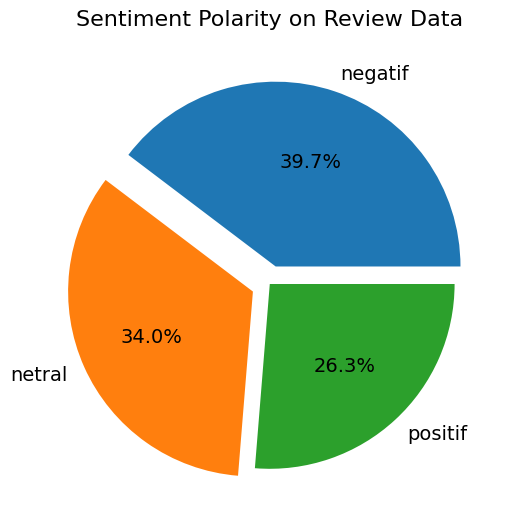

In [18]:
fig, ax = plt.subplots(figsize=(6, 6))

sizes = [count for count in clean_df['polarity'].value_counts()]

labels = list(clean_df['polarity'].value_counts().index)

explode = (0.1, 0.1, 0)

ax.pie(x=sizes, labels=labels, autopct='%1.1f%%', explode=explode, textprops={'fontsize': 14})
ax.set_title('Sentiment Polarity on Review Data', fontsize=16, pad=20)

plt.show()

Dari visualisasi diatas, dapat diketahui bahwa persentase dari kelas/label netral adalah 34.0%, positif adalah 26.3%, dan sisanya negatif 39.7%. Ini menunjukkan bahwa sebagian besar ulasan merupakan ulasan negatig.

2. Visualisasi Word Cloud

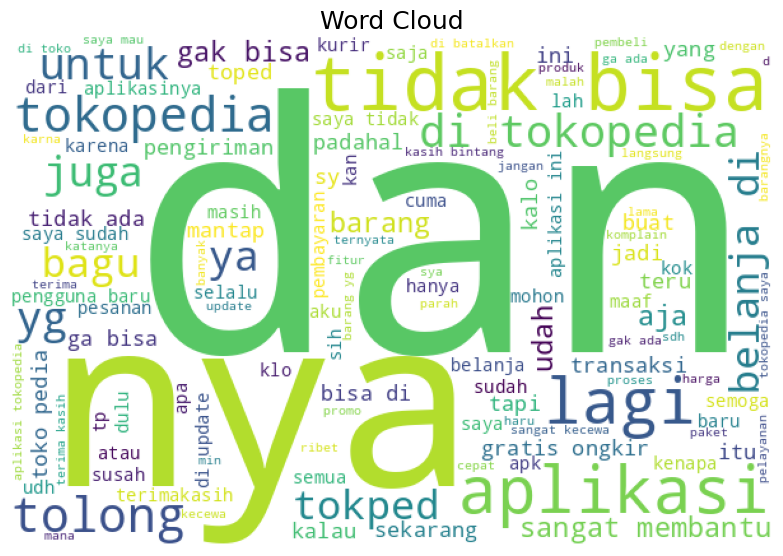

In [20]:
list_words = ''

for tweet in clean_df['text_stopword']:
    for word in tweet:
        list_words += ' ' + (word)

wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_words)

fig, ax = plt.subplots(figsize=(8, 6))

ax.set_title('Word Cloud', fontsize=18)
ax.grid(False)
ax.imshow((wordcloud))

fig.tight_layout(pad=0)

ax.axis('off')
plt.show()

Kata yang sering muncul pada komentar/data ulasan dapat dilihat dari visualisasi ini. Adapun beberapa kata yang paling sering muncul merupakan kata sambung seperti "dan", "nya", "tidak bisa", dan lain-lain

3. Bar Chart

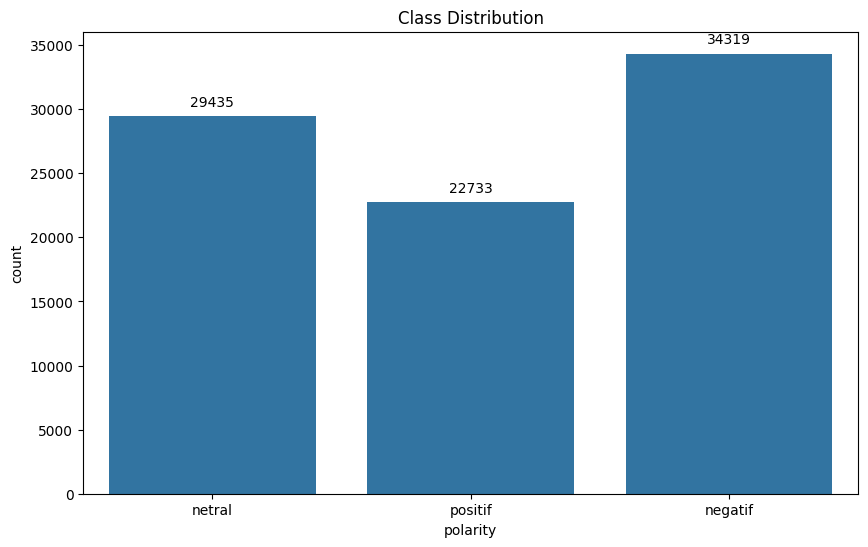

In [21]:
plt.figure(figsize=(10, 6))

class_dist_plot = sns.countplot(x='polarity', data=clean_df)
plt.title('Class Distribution')

for p in class_dist_plot.patches:
    class_dist_plot.annotate(format(p.get_height(), '.0f'),
                              (p.get_x() + p.get_width() / 2., p.get_height()),
                              ha='center', va='center',
                              xytext=(0, 10),
                              textcoords='offset points')

plt.show()



Dari visualisasi ini, dapat diketahui bahwa jumlah data komentar/ulasan dengan label netral adalah 29435, untuk label negatif ada 34319 komentar/ulasan, dan untuk label positif ada 22733 komentar/ulasan. Ini sesuai dengan hasil pelabelan yang telah dilakukan sebelumnya.

# RNN

Untuk deep learning pada proyek ini, digunakan RNN (Recurrent Neural Network).

In [22]:
X = clean_df['text_akhir']
y = clean_df['polarity']

In [23]:
le = LabelEncoder()
y = le.fit_transform(y)

print("Mapping label:", dict(zip(le.classes_, le.transform(le.classes_))))

Mapping label: {'negatif': np.int64(0), 'netral': np.int64(1), 'positif': np.int64(2)}


In [24]:
max_words = 5000
max_len = 100

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X)

X_seq = tokenizer.texts_to_sequences(X)
X_pad = pad_sequences(X_seq, maxlen=max_len, padding='post')

In [25]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_pad, y, test_size=0.2, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

Untuk pembagian data, digunakan komposisi 80:10:10. 80% untuk data latih, 10% untuk data validasi, dan 10% sisanya untuk data uji

In [26]:
X_train = np.array(X_train, dtype='int32')
X_val = np.array(X_val, dtype='int32')
X_test = np.array(X_test, dtype='int32')

y_train = np.array(y_train, dtype='int32')
y_val = np.array(y_val, dtype='int32')
y_test = np.array(y_test, dtype='int32')

In [27]:
model = Sequential([
    Embedding(input_dim=max_words, output_dim=64, input_length=max_len),
    SimpleRNN(64),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [28]:
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [29]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val, y_val)
)

Epoch 1/10
1082/1082 ━━━━━━━━━━━━━━━━━━━━ 48s 42ms/step - accuracy: 0.8050 - loss: 0.5109 - val_accuracy: 0.8481 - val_loss: 0.4173
Epoch 2/10
1082/1082 ━━━━━━━━━━━━━━━━━━━━ 43s 40ms/step - accuracy: 0.8571 - loss: 0.3684 - val_accuracy: 0.8692 - val_loss: 0.3515
Epoch 3/10
1082/1082 ━━━━━━━━━━━━━━━━━━━━ 45s 42ms/step - accuracy: 0.8805 - loss: 0.3069 - val_accuracy: 0.8755 - val_loss: 0.3248
Epoch 4/10
1082/1082 ━━━━━━━━━━━━━━━━━━━━ 81s 41ms/step - accuracy: 0.8863 - loss: 0.2932 - val_accuracy: 0.8730 - val_loss: 0.3318
Epoch 5/10
1082/1082 ━━━━━━━━━━━━━━━━━━━━ 80s 39ms/step - accuracy: 0.8780 - loss: 0.3203 - val_accuracy: 0.8617 - val_loss: 0.3547
Epoch 6/10
1082/1082 ━━━━━━━━━━━━━━━━━━━━ 43s 40ms/step - accuracy: 0.8562 - loss: 0.3753 - val_accuracy: 0.8859 - val_loss: 0.3431
Epoch 7/10
1082/1082 ━━━━━━━━━━━━━━━━━━━━ 82s 40ms/step - accuracy: 0.8038 - loss: 0.4754 - val_accuracy: 0.8709 - val_loss: 0.3234
Epoch 8/10
1082/1082 ━━━━━━━━━━━━━━━━━━━━ 44s 41ms/step - accuracy: 0.8714 -

Pada bagian pelatihannya, digunakan 10 epochs atau 10 iterasi pelatihan, dengan batch size 64 karena memiliki keseimbangan stabilitas dan kecepatan yang sesuai dengan data yang digunakan.

In [30]:
loss, acc = model.evaluate(X_test, y_test)
print(f"Akurasi Test: {acc * 100:.2f}%")

271/271 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8569 - loss: 0.3075
Akurasi Test: 85.69%


Hasil akurasi yang diperoleh dari pelatihan menggunakan RNN adalah 85,69% dimana akurasi ini menunjukkan bahwa model belajar dengan baik. Selanjutnya adalah menyimpan model untuk pembuatan inference sederhana

In [31]:
model.save("model_rnn.h5")

In [32]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [33]:
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

# Data Splitting dan Ekstraksi Fitur dengan TF-IDF

Adapun data splitting dan ekstraksi fitur ini akan digunakan untuk model machine learning. Pada bagian ini, data yang digunakan akan dibagi menjadi data latih dan data uji/data test. Adapun pembagian data yang digunakan adalah 80:20 dimana 80% data akan digunakan sebagai data latih dan 20% sisanya akan digunakan untuk data tes.

In [34]:
X = clean_df['text_akhir']
y = clean_df['polarity']

tfidf = TfidfVectorizer(max_features=1000, min_df=17, max_df=0.8 )
X_tfidf = tfidf.fit_transform(X)

features_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())

features_df

X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

# Modeling dengan Machine Learning

1. Random Forest

In [35]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier()

random_forest.fit(X_train.toarray(), y_train)

y_pred_train_rf = random_forest.predict(X_train.toarray())
y_pred_test_rf = random_forest.predict(X_test.toarray())

accuracy_train_rf = accuracy_score(y_pred_train_rf, y_train)
accuracy_test_rf = accuracy_score(y_pred_test_rf, y_test)

print(f"Random Forest - accuracy_train: {round(accuracy_train_rf * 100)}%")
print(f"Random Forest - accuracy_test: {round(accuracy_test_rf*100)}%")

Random Forest - accuracy_train: 98%
Random Forest - accuracy_test: 90%


Model pertama ada Random Forest. Melalui model ini, akurasi pelatihan adalah 98% dan akurasi testing yang diperoleh adalah 90% dimana akurasi ini terbilang tinggi sehingga dapat dikatakan model mampu memberikan prediksi yang cukup akurat.

2. Logistic Regression

In [36]:
from sklearn.linear_model import LogisticRegression

logistic_regression = LogisticRegression()

logistic_regression.fit(X_train.toarray(), y_train)

y_pred_train_lr = logistic_regression.predict(X_train.toarray())
y_pred_test_lr = logistic_regression.predict(X_test.toarray())

accuracy_train_lr = accuracy_score(y_pred_train_lr, y_train)

accuracy_test_lr = accuracy_score(y_pred_test_lr, y_test)

print(f"Logistic Regression - accuracy_train: {round(accuracy_train_lr * 100)}%")
print(f"Logistic Regression - accuracy_test: {round(accuracy_test_lr*100)}%")

Logistic Regression - accuracy_train: 94%
Logistic Regression - accuracy_test: 93%


Model yang kedua ada Logistic Regression. Melalui model ini, akurasi pelatihan dan akurasi testing yang diperoleh adalah 94% dan 93% dimana akurasi ini cukup tinggi sehingga dapat dikatakan model mampu memberikan prediksi yang cukup akurat.

3. Decision Tree

In [37]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier()

decision_tree.fit(X_train.toarray(), y_train)

y_pred_train_dt = decision_tree.predict(X_train.toarray())
y_pred_test_dt = decision_tree.predict(X_test.toarray())

accuracy_train_dt = accuracy_score(y_pred_train_dt, y_train)
accuracy_test_dt = accuracy_score(y_pred_test_dt, y_test)

print(f"Decision Tree - accuracy_train: {round(accuracy_train_lr * 100)}%")
print(f"Decision Tree - accuracy_test: {round(accuracy_test_lr*100)}%")

Decision Tree - accuracy_train: 94%
Decision Tree - accuracy_test: 93%


Model yang Ketiga ada Decision Tree. Sama seperti hasil model Logistic Regression sebelumnya, model Decision Tree menghasilkan akurasi pelatihan dan akurasi testing yang diperoleh adalah 94% dan 93% dimana akurasi ini cukup tinggi sehingga dapat dikatakan model mampu memberikan prediksi yang cukup akurat.

# Inference sederhana

Terakhir adalah inference sederhana, dimana pada inference ini digunakan fungsi predict_sentiment_rnn untuk melakukan prediksi komentar positif, negatif atau netral sesuai dengan input/masukan yang dierikan

In [38]:
def predict_sentiment_rnn(text):
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=max_len, padding='post')

    pred = model.predict(padded)
    label = np.argmax(pred)

    return le.inverse_transform([label])[0]

In [41]:
print(predict_sentiment_rnn("Aplikasinya kurang bagus"))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
negatif


Prediksi yang diberikan masih kurang akurat, hal ini bisa dipengaruhi karena dataset atau sesi pelatihan yang kurang

In [42]:
!pip freeze > requirements.txt